# $\text{Taller - Redes Neuronales Artificiales: Regresión}$

##$\text{Modelado de la Calidad del Aire en Italia (2004-2005)}$

---

##$\text{Tabla de Contenido}$

1. $\text{Importar Librerías}$
2. $\text{Introducción a Redes Neuronales}$
    - $\text{¿Qué es una ANN?}$
    - $\text{Componentes principales de una ANN}$
3. $\text{Comprendiendo los Datos}$
    - $\text{Descripción del Dataset}$
    - $\text{Carga y Exploración de Datos}$
    - $\text{Limpieza y Preprocesamiento de Datos}$
4. $\text{Entrenamiento de un Modelo ANN}$
    - $\text{Preparación de Datos para Entrenamiento}$
    - $\text{Definición del Modelo}$
    - $\text{Entrenamiento y Validación}$
5. $\text{Evaluación y Visualización}$
    - $\text{Métricas de Rendimiento}$
    - $\text{Visualización de Resultados}$
6. $\text{Conclusiones}$

## 1. $\text{Importar Librerías}$

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

### Función RealTimePlotCallback

In [ ]:
from sklearn.metrics import r2_score
from IPython import display
import matplotlib.pyplot as plt

class RealTimePlotCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.epochs = []
        self.loss = []
        self.val_loss = []
        self.mae = []
        self.val_mae = []
        self.r2 = []

    def on_epoch_end(self, epoch, logs=None):
        self.epochs.append(epoch + 1)
        self.loss.append(logs['loss'])
        self.val_loss.append(logs['val_loss'])
        self.mae.append(logs['mae'])
        self.val_mae.append(logs['val_mae'])

        # Calcular R²
        y_pred = self.model.predict(self.X_val, verbose=0)
        self.r2.append(r2_score(self.y_val, y_pred))

        # Limpiar y actualizar gráficos
        display.clear_output(wait=True)
        plt.figure(figsize=(18, 5))

        # Gráfica de Pérdida (Loss)
        plt.subplot(1, 3, 1)
        plt.plot(self.epochs, self.loss, 'b-', label='Entrenamiento', linewidth=2)
        plt.plot(self.epochs, self.val_loss, 'r-', label='Validación', linewidth=2)
        plt.title('Error (MSE)', fontsize=14, fontweight='bold')
        plt.xlabel('Época', fontsize=12, fontweight='bold')
        plt.grid(True)
        plt.legend()

        # Gráfica de MAE
        plt.subplot(1, 3, 2)
        plt.plot(self.epochs, self.mae, 'b-', label='Entrenamiento', linewidth=2)
        plt.plot(self.epochs, self.val_mae, 'r-', label='Validación', linewidth=2)
        plt.title('Error Absoluto Medio (MAE)', fontsize=14, fontweight='bold')
        plt.xlabel('Época', fontsize=12, fontweight='bold')
        plt.grid(True)
        plt.legend()

        # Gráfica de R²
        plt.subplot(1, 3, 3)
        plt.plot(self.epochs, self.r2, 'g-', label='R²', linewidth=2)
        plt.title('Coeficiente R²', fontsize=14, fontweight='bold')
        plt.xlabel('Época', fontsize=12, fontweight='bold')
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

## 2. $\text{Introducción a Redes Neuronales}$

**¿Qué es una ANN?**

Las redes neuronales artificiales (ANN) son modelos computacionales inspirados en la estructura y el funcionamiento del cerebro humano. Imagina un sistema complejo de nodos interconectados (neuronas artificiales) que, en lugar de seguir reglas programadas, aprenden a identificar patrones y relaciones complejas a partir de los datos. Estos modelos son la base del aprendizaje profundo y permiten resolver una amplia variedad de problemas, desde la clasificación de imágenes hasta la predicción de series temporales. En este taller, te introduciremos a la base teórica de cómo funcionan las ANN y cómo puedes utilizarlas en problemas de modelado, como la predicción de la calidad del aire.

### Componentes principales de una ANN:

1. **Capas de Entrada:** Es la puerta de entrada de la red, donde ingresan las características o variables de nuestro dataset. Por ejemplo, en nuestro problema de calidad del aire, las variables como la concentración de CO, la temperatura o la humedad serían parte de la capa de entrada.
2. **Capas Ocultas:** Son las capas intermedias donde se realizan los cálculos principales. Cada neurona en una capa oculta procesa la información recibida de la capa anterior, transformándola mediante funciones de activación no lineales. Estas funciones son cruciales para que la red pueda aprender relaciones complejas y no lineales en los datos.
3. **Capa de Salida:** Es la última capa de la red, donde se generan las predicciones o resultados finales. La naturaleza de esta capa depende del tipo de tarea que queramos resolver. En nuestro caso, donde realizaremos **regresión**, la capa de salida producirá una predicción numérica continua, como la concentración de un contaminante
4. **Funciones de Activación:** Son funciones matemáticas que introducen no linealidad en la red. Cada neurona, antes de propagar su señal a la siguiente capa, pasa su valor por una función de activación. Estas funciones son esenciales para que las redes neuronales puedan modelar relaciones complejas que no serían posibles con modelos lineales.

---


## 3. $\text{Comprendiendo los Datos}$


### **Descripción del Dataset**:

Este dataset contiene **9,358 mediciones horarias** de calidad del aire recolectadas por un dispositivo multisensor en una zona urbana altamente contaminada de Italia, entre marzo de 2004 y febrero de 2005. Los datos incluyen respuestas de sensores químicos y concentraciones reales de contaminantes medidas por analizadores certificados, lo que lo convierte en un recurso valioso para estudiar patrones de contaminación atmosférica y calibrar sensores en condiciones reales.

**Variables Principales**:

* **`Date`**: Fecha de la medición en formato `DD/MM/YYYY`.  
* **`Time`**: Hora de la medición en formato `HH.MM.SS`.  
* **`CO(GT)`**: Concentración de **monóxido de carbono (CO)** en el aire, medida en miligramos por metro cúbico (`mg/m³`). Este contaminante es un indicador clave de la polución urbana.  
* **`PT08.S1(CO)`**: Respuesta del sensor de óxido de estaño, diseñado para detectar **monóxido de carbono (CO)**. Esta variable puede ayudar a entender la respuesta de los sensores en situaciones reales.
* **`NMHC(GT)`**: Concentración de hidrocarburos no metánicos (NMHC), expresada en microgramos por metro cúbico (`µg/m³`). Los NMHC son importantes en la formación de ozono y otros contaminantes secundarios. .  
* **`C6H6(GT)`**: Concentración de benceno en `µg/m³`.  El benceno es un compuesto tóxico y cancerígeno
* **`PT08.S2(NMHC)`**: Respuesta del sensor de dióxido de titanio (NMHC objetivo nominal).  
* **`NOx(GT)`**: Concentración de óxidos de nitrógeno (NOx) en `ppb`.  Los NOx son importantes precursores de la formación de smog y lluvia ácida.
* **`PT08.S3(NOx)`**: Respuesta del sensor de óxido de tungsteno (NOx objetivo nominal).  
* **`NO2(GT)`**: Concentración de dióxido de nitrógeno (NO₂) en `µg/m³`.  El NO₂ es un contaminante significativo en zonas urbanas.
* **`PT08.S4(NO2)`**: Respuesta del sensor de óxido de tungsteno (NO₂ objetivo nominal).  
* **`PT08.S5(O3)`**: Respuesta del sensor de óxido de indio (O₃ objetivo nominal).  
* **`T`**: Temperatura ambiental en grados Celsius (`°C`).  
* **`RH`**: Humedad relativa en porcentaje (`%`).  
* **`AH`**: Humedad absoluta (unidad adimensional).  

#### **Contexto y Notas Clave**:
- **Origen**: Los datos fueron recolectados a nivel de calle, en una ciudad italiana, lo que refleja la exposición directa a la contaminación del aire en un entorno urbano real. La precisión de las mediciones y el hecho de contar con datos tanto de sensores como de analizadores certificados hacen que este dataset sea muy valioso para fines de investigación.
- **Temporalidad**: Cubre un año completo de mediciones (horario continuo).  
- **Uso**: Solo para investigación (no comercial).  
- **Desafíos**:  
  - La presencia de valores faltantes, identificados como **-200**, requiere la implementación de técnicas de limpieza y preprocesamiento de datos.
  - Deriva de sensores y efectos cruzados entre contaminantes.  
  - Ideal para estudiar correlaciones entre variables ambientales y contaminación.  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Cargar y explorar el dataset

In [ ]:
data_air = pd.read_csv('/content/drive/MyDrive/UNAL/Semestre III/ML/Datas/AirQualityUCI.csv', sep=';')

In [ ]:
# Imprima las primeras 5 filas
data_air.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


In [ ]:
print("\nEstadísticas descriptivas:")
data_air.describe()


Estadísticas descriptivas:


,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,NaN,NaN
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,NaN,NaN
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,NaN,NaN
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,NaN,NaN
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,NaN,NaN


In [ ]:
data_air.tail(115)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
9356,04/04/2005,14.00.00,"2,2",1071.0,-200.0,"11,9",1047.0,265.0,654.0,168.0,1129.0,816.0,"28,5","13,1","0,5028",NaN,NaN
9357,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9358,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Limpieza

In [ ]:
data_air.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB


In [ ]:
data_air.drop(['Unnamed: 15', 'Unnamed: 16'], axis=1, inplace=True)

In [ ]:
data_air.dropna(inplace=True)

data_air.reset_index(drop=True, inplace=True)

In [ ]:
data_air.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9352,04/04/2005,10.00.00,"3,1",1314.0,-200.0,"13,5",1101.0,472.0,539.0,190.0,1374.0,1729.0,"21,9","29,3","0,7568"
9353,04/04/2005,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,04/04/2005,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,04/04/2005,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"
9356,04/04/2005,14.00.00,"2,2",1071.0,-200.0,"11,9",1047.0,265.0,654.0,168.0,1129.0,816.0,"28,5","13,1","0,5028"


In [ ]:
columnas_con_comas = ["CO(GT)", "C6H6(GT)", "T", "RH", "AH"]
for col in columnas_con_comas:
    data_air[col] = data_air[col].str.replace(",", ".").astype(float)

In [ ]:
# Reemplazar -200 por NaN (si aplica)
data_air = data_air.replace(-200, np.nan)

# Contar valores faltantes por columna
print(data_air.isnull().sum())

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [ ]:
# Cuenta cuántos valores son -200 en todo el DataFrame
conteo_menos_200 = (data_air == -200).sum().sum()

print(f"El número de valores -200 en el dataset es: {conteo_menos_200}")

El número de valores -200 en el dataset es: 0


In [ ]:
# 1. Eliminar columnas con demasiados valores NaN
threshold = 0.5 * len(data_air)
data_air = data_air.dropna(thresh=threshold, axis=1)

In [ ]:
# 3. Rellenar valores restantes
# Identificar columnas numéricas
numeric_columns = data_air.select_dtypes(include=["number"]).columns

# Rellenar valores NaN con la media únicamente en las columnas numéricas
data_air[numeric_columns] = data_air[numeric_columns].fillna(data_air[numeric_columns].mean())

# Verificar si quedan valores NaN
print(data_air.isna().sum())


Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


### Gráfico Serie de tiempo de **CO(GT)**

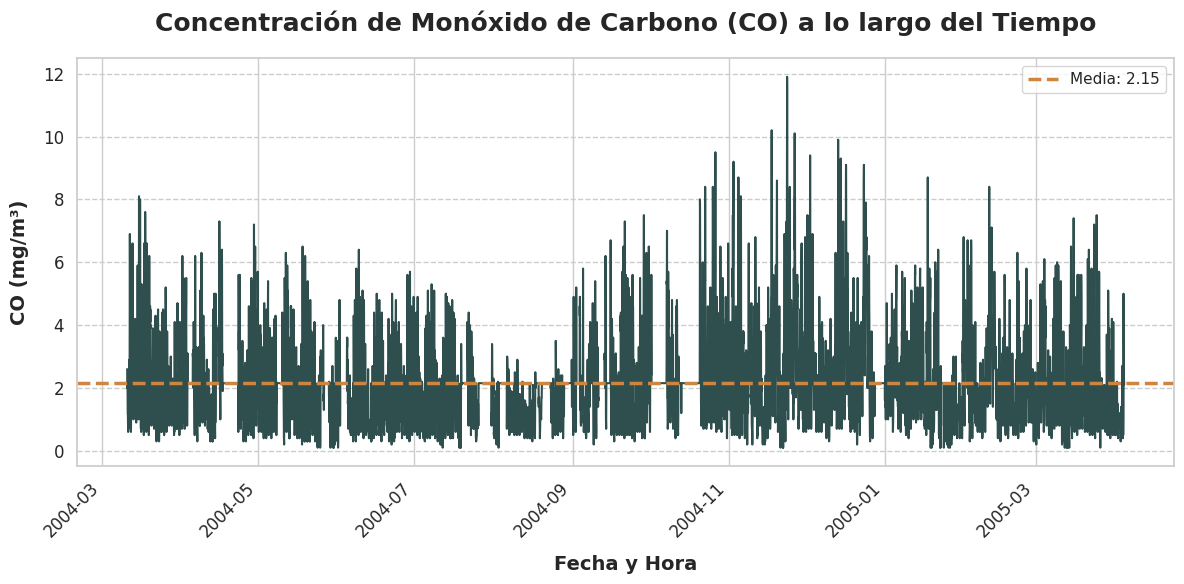

In [ ]:
# Arreglar el formato de Date y Time
data_air['DateTime'] = pd.to_datetime(
    data_air['Date'] + ' ' + data_air['Time'],
    format='%d/%m/%Y %H.%M.%S'
)

plt.figure(figsize=(12, 6))
sns.lineplot(x='DateTime', y='CO(GT)', data=data_air, color='darkslategrey', linewidth=1.5)
plt.title('Concentración de Monóxido de Carbono (CO) a lo largo del Tiempo',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Fecha y Hora', fontsize=14, labelpad=10, weight = 'bold')
plt.ylabel('CO (mg/m³)', fontsize=14, labelpad=10, weight = 'bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--')

# línea horizontal en la media (opcional)
mean_co = data_air['CO(GT)'].mean()
plt.axhline(mean_co, color='peru', linestyle='--', linewidth=2.5, label=f'Media: {mean_co:.2f}')
plt.legend()

# Ajustar márgenes y mostrar el gráfico
plt.tight_layout()
plt.show()

### Histograma de CO(GT)

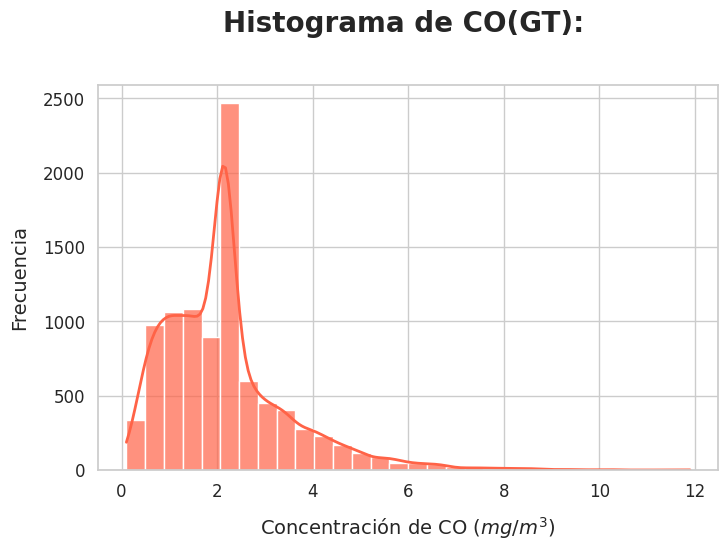

In [ ]:
# Crear el histograma
plt.figure(figsize=(8, 5))
sns.histplot(
    data_air['CO(GT)'],
    bins=30,
    kde=True,
    color='tomato',
    alpha=0.7,
    line_kws={'linewidth': 2, 'color': 'tomato'}
)
plt.title('Histograma de CO(GT): \n', fontsize=20, fontweight='bold', pad=15)
plt.xlabel('Concentración de CO ($ mg/m^3 $)', fontsize=14, labelpad=10)
plt.ylabel('Frecuencia', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

### Grafico scatter entre Óxidos de Nitrógeno (NOx) y Dióxido de Nitrógeno (NO2)

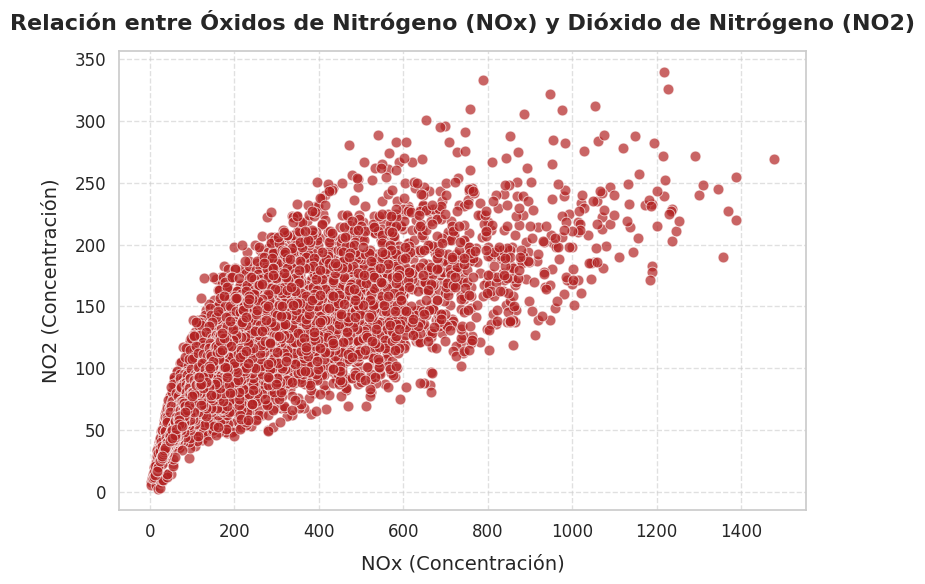

In [ ]:
plt.figure(figsize=(8, 6))
# Crea el gráfico de dispersión con seaborn
sns.scatterplot(x='NOx(GT)', y='NO2(GT)', data=data_air,
                alpha=0.7, edgecolor='w', s=60, color='firebrick')

plt.title('Relación entre Óxidos de Nitrógeno (NOx) y Dióxido de Nitrógeno (NO2)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('NOx (Concentración)', fontsize=14, labelpad=10)
plt.ylabel('NO2 (Concentración)', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Gráfico scatter entre CO y Sensor de Monóxido de Carbono

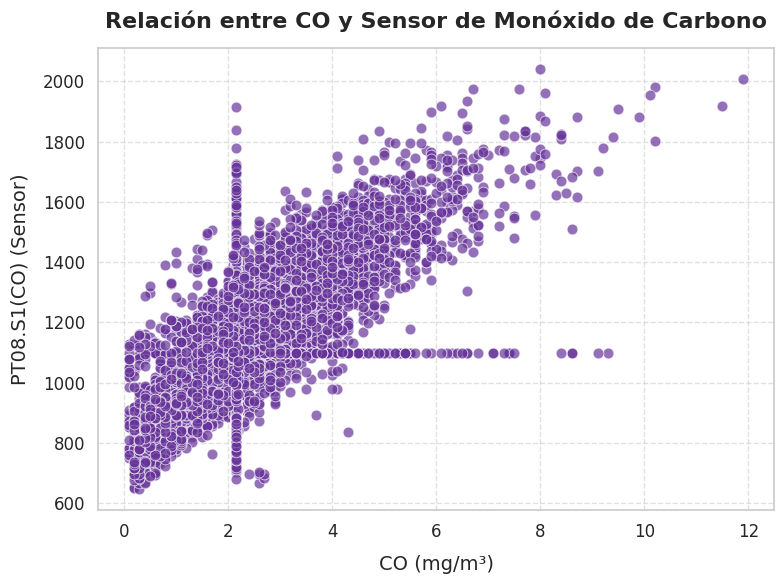

In [ ]:
# Crea el gráfico de dispersión con seaborn
plt.figure(figsize=(8, 6))
sns.scatterplot(x='CO(GT)', y='PT08.S1(CO)', data=data_air,
                alpha=0.7, edgecolor='w', s=60, color='rebeccapurple')

plt.title('Relación entre CO y Sensor de Monóxido de Carbono',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('CO (mg/m³)', fontsize=14, labelpad=10)
plt.ylabel('PT08.S1(CO) (Sensor)', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Gráfico correlaciones

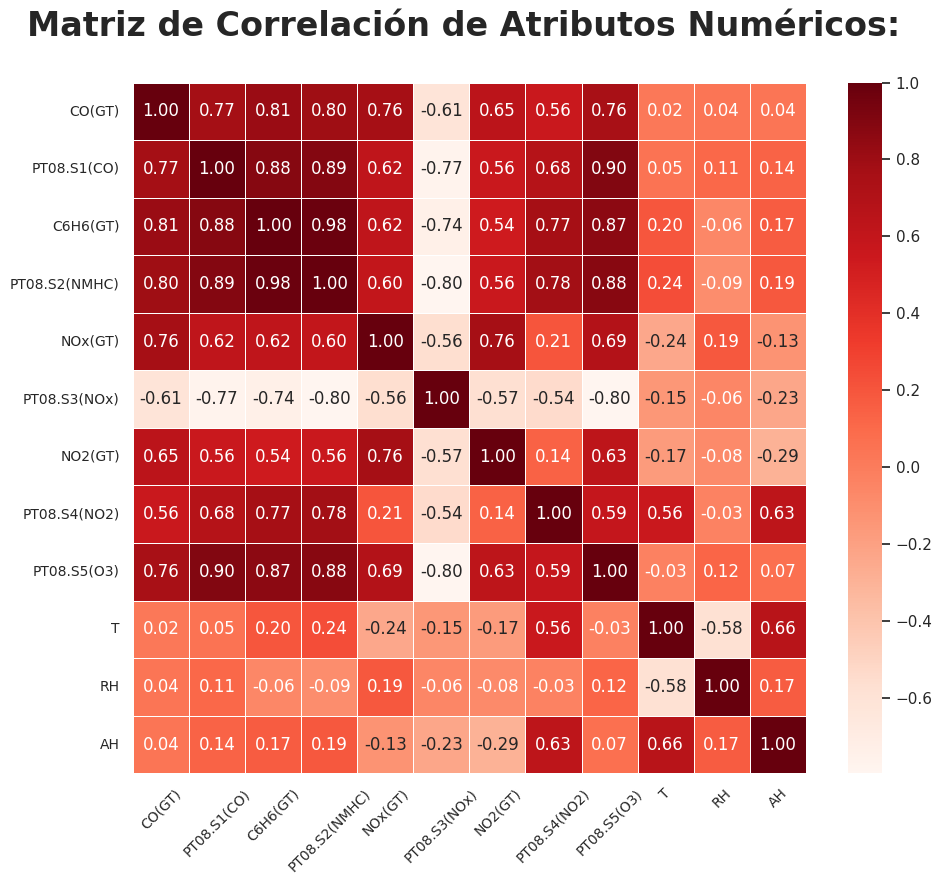

In [ ]:
# Filtrar columnas numéricas

numeric_cols = data_air.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 9))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='Reds',
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'shrink': 1}
)
plt.title('Matriz de Correlación de Atributos Numéricos: \n', fontsize=24, fontweight='bold')
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

## 4. $\text{Entrenamiento de un Modelo ANN}$

### Preparación de Datos para Entrenamiento

In [ ]:
# Separar features y target
X = data_air.iloc[:, 3:-1].values
y = data_air.iloc[:, 2].values

# Estandarizar
sc = StandardScaler()
X_sc = sc.fit_transform(X)

In [ ]:
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_sc, y, test_size=0.2,
                                                    random_state=47)

### Definición del Modelo

In [ ]:
# Definir el modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='elu')  # Salida para regresión
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae', 'mse', 'r2_score'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Entrenamiento y Validación

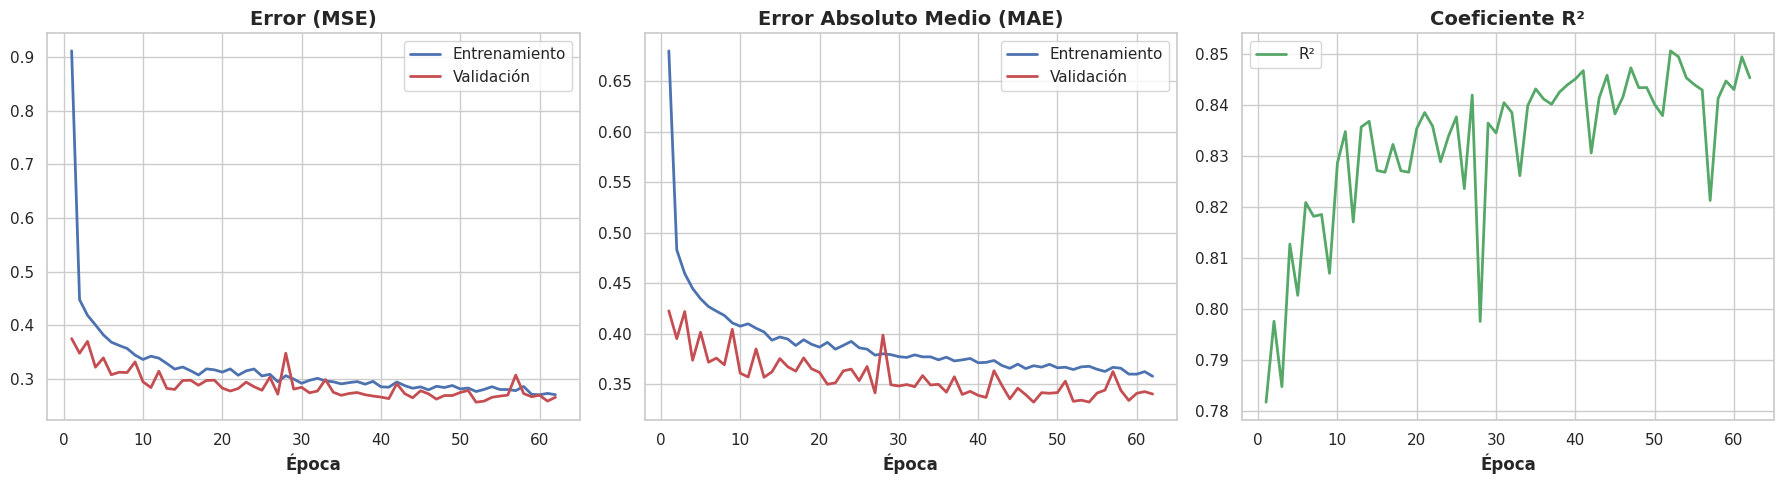

234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2603 - mae: 0.3535 - mse: 0.2603 - r2_score: 0.8474 - val_loss: 0.2659 - val_mae: 0.3402 - val_mse: 0.2659 - val_r2_score: 0.8454


In [ ]:
# Entrenar el modelo
rt_plot = RealTimePlotCallback(X_test, y_test)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),  # Datos de validación
    callbacks=[rt_plot, early_stop],
    verbose=1
)

## 5. $\text{Evaluación y Visualización}$

In [ ]:
# método para obtener en un diciconario el mse, mae y la pérdida

historia = history.history

In [ ]:
# imprimir claves del diccionario

print(historia.keys())

dict_keys(['loss', 'mae', 'mse', 'r2_score', 'val_loss', 'val_mae', 'val_mse', 'val_r2_score'])


### Gráfica de MSE vs épocas

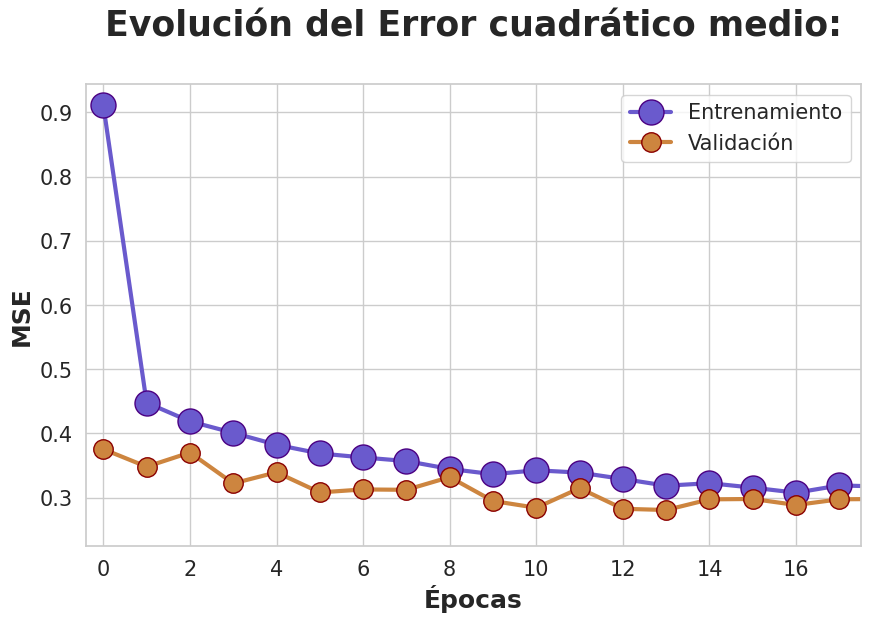

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(historia['mse'], color='slateblue', linewidth=3, marker='o', markersize = 18, mec = 'indigo')
plt.plot(historia['val_mse'], color='peru', linewidth=3, marker='o', markersize = 14, mec = 'darkred')
plt.title('Evolución del Error cuadrático medio:\n', fontsize=25, fontweight='bold')
plt.xlabel('Épocas', fontsize=18, fontweight='bold')
plt.ylabel('MSE', fontsize=18, fontweight='bold')
plt.legend(['Entrenamiento', 'Validación'], fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim([-0.4,17.5])
plt.grid(True)
plt.show()

### Gráfica del $R^{2}$ vs épocas

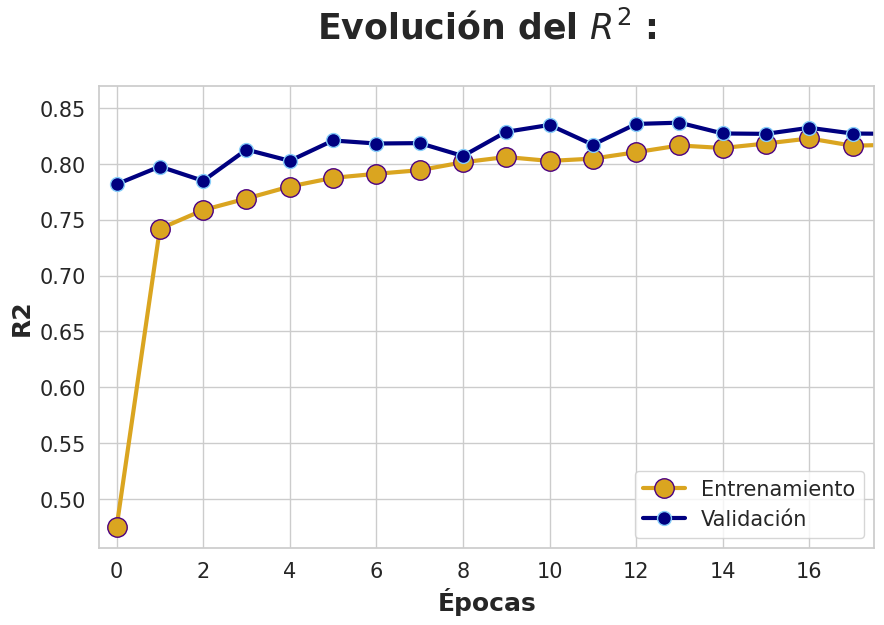

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(historia['r2_score'], color='goldenrod', linewidth=3, marker='o', markersize = 14, mec = 'indigo')
plt.plot(historia['val_r2_score'], color='navy', linewidth=3, marker='o', markersize = 10, mec = 'lightskyblue')
plt.title('Evolución del $R^{2}$ :\n', fontsize=25, fontweight='bold')
plt.xlabel('Épocas', fontsize=18, fontweight='bold')
plt.ylabel('R2', fontsize=18, fontweight='bold')
plt.legend(['Entrenamiento', 'Validación'], fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim([-0.4,17.5])
plt.grid(True)
plt.show()

In [ ]:
# Predecir en los datos de prueba
predicción = model.predict(X_test)

59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


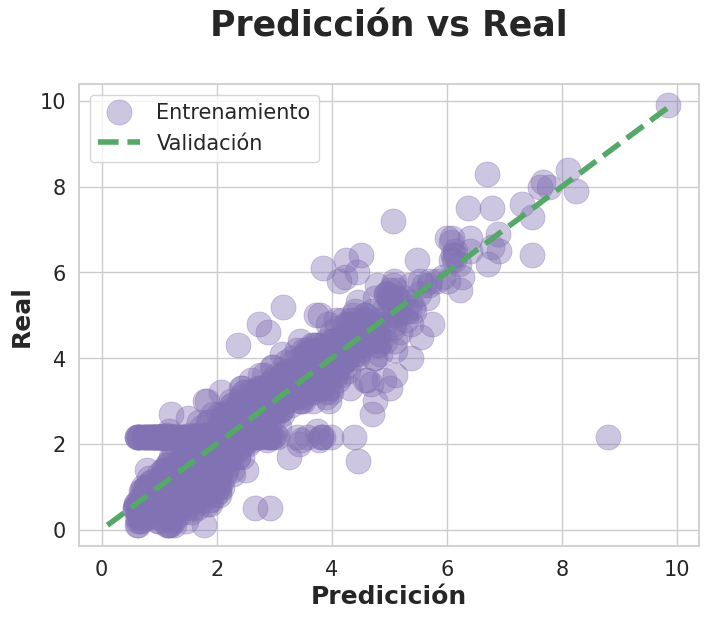

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(predicción, y_test, 'mo', label='Predicción vs Real', markersize = 18, mew = 0.6, alpha = 0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', lw=4)
plt.title('Predicción vs Real\n', fontsize=25, fontweight='bold')
plt.xlabel('Predicición', fontsize=18, fontweight='bold')
plt.ylabel('Real', fontsize=18, fontweight='bold')
plt.legend(['Entrenamiento', 'Validación'], fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True)
plt.show()

In [ ]:
print(f'El R^2 score es = {r2_score(y_test, predicción)}\n')
print(f'El error absoluto medio es = {mean_absolute_error(y_test, predicción)}\n')
print(f'El error cuadrático medio es = {mean_squared_error(y_test, predicción)}\n')

El R^2 score es = 0.8506407375129431

El error absoluto medio es = 0.3329837388189

El error cuadrático medio es = 0.2568260083608202

